In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean styling theme for our visualizations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the data from your cleaned data directory
df = pd.read_csv(r'C:\Users\varsh\Downloads\Real estate prediction model\data\cleaned\bengaluru_house_data_clean.csv')
df.head()

,area_type,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,Devarabeesana Halli,1672.0,3,2,150.0,3
1,Built-up Area,Devarabeesana Halli,1750.0,3,3,149.0,3
2,Super built-up Area,Devarabeesana Halli,1750.0,3,2,150.0,3
3,Super built-up Area,Devarachikkanahalli,1250.0,2,3,44.0,3
4,Super built-up Area,Devarachikkanahalli,1250.0,2,2,40.0,2


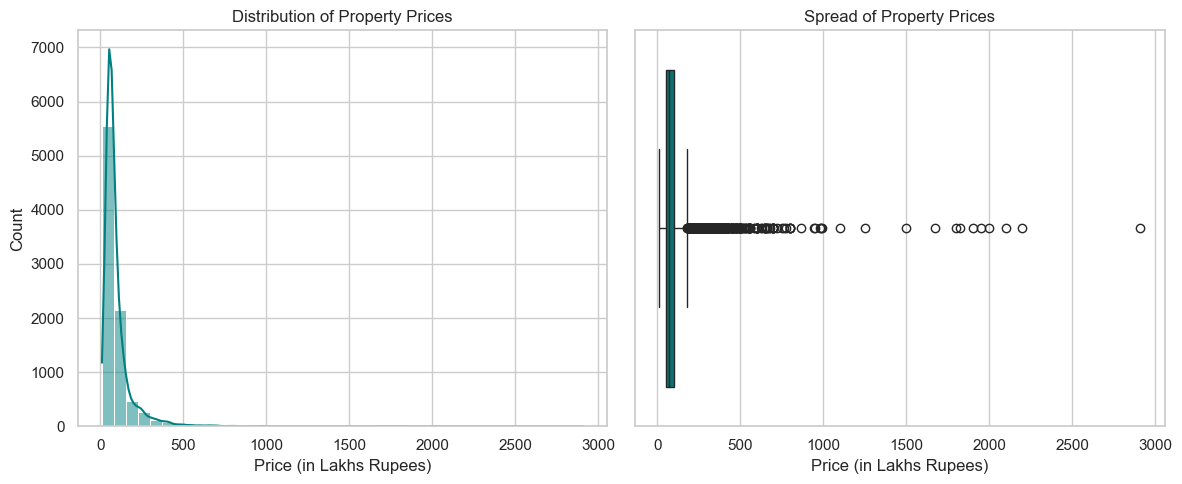

Median Price: ₹68.00 Lakhs
Price Skewness: 8.92


In [2]:
plt.figure(figsize=(12, 5))

# Plot Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(df['price'], bins=40, kde=True, color='teal')
plt.title('Distribution of Property Prices')
plt.xlabel('Price (in Lakhs Rupees)')
plt.ylabel('Count')

# Plot Boxplot to look at quantiles
plt.subplot(1, 2, 2)
sns.boxplot(x=df['price'], color='teal')
plt.title('Spread of Property Prices')
plt.xlabel('Price (in Lakhs Rupees)')

plt.tight_layout()
plt.show()

# Print skewness metrics
print(f"Median Price: ₹{df['price'].median():.2f} Lakhs")
print(f"Price Skewness: {df['price'].skew():.2f}")

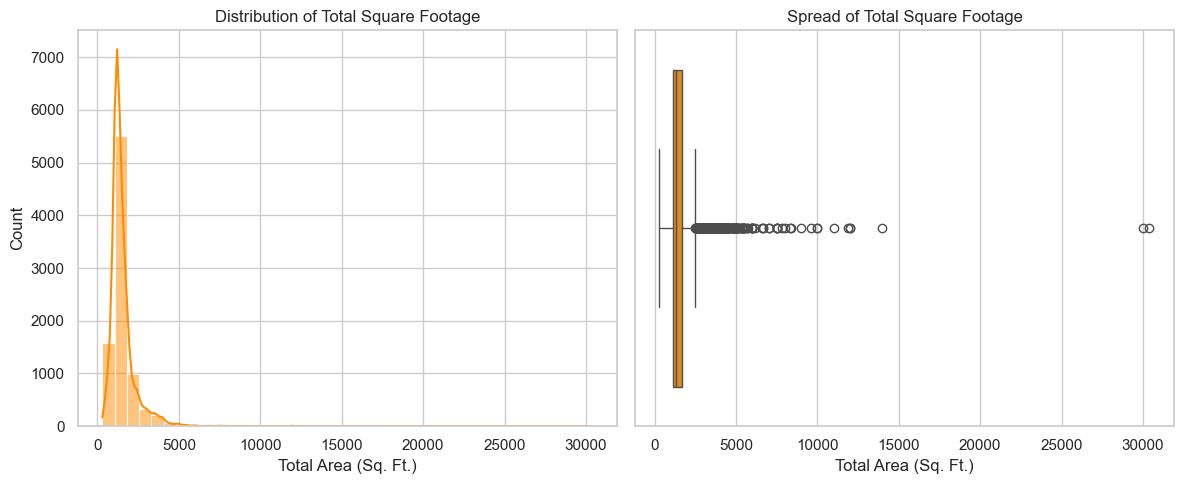

Average Area: 1523.82 Sq. Ft.
Most common Area range: 1110 to 1670 Sq. Ft.


In [3]:
plt.figure(figsize=(12, 5))

# Plot Area Distribution
plt.subplot(1, 2, 1)
sns.histplot(df['total_sqft'], bins=40, kde=True, color='darkorange')
plt.title('Distribution of Total Square Footage')
plt.xlabel('Total Area (Sq. Ft.)')
plt.ylabel('Count')

# Plot Boxplot for Area
plt.subplot(1, 2, 2)
sns.boxplot(x=df['total_sqft'], color='darkorange')
plt.title('Spread of Total Square Footage')
plt.xlabel('Total Area (Sq. Ft.)')

plt.tight_layout()
plt.show()

print(f"Average Area: {df['total_sqft'].mean():.2f} Sq. Ft.")
print(f"Most common Area range: {df['total_sqft'].quantile(0.25):.0f} to {df['total_sqft'].quantile(0.75):.0f} Sq. Ft.")

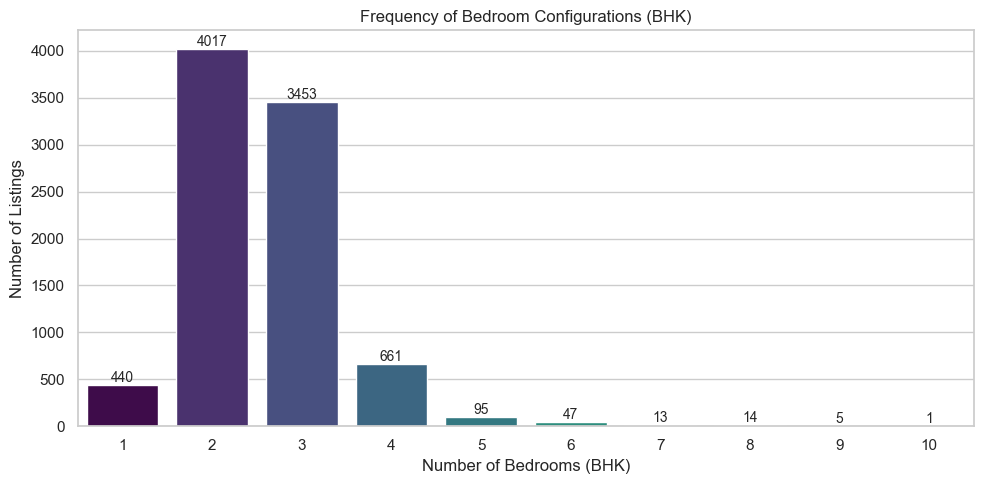

BHK Share Percentage Across Dataset:
bhk
2     45.929568
3     39.480906
4      7.557741
1      5.030871
5      1.086211
6      0.537389
8      0.160073
7      0.148639
9      0.057169
10     0.011434
Name: proportion, dtype: float64


In [4]:
plt.figure(figsize=(10, 5))

# Create a clean count plot ordered by bedroom volume
sns.countplot(data=df, x='bhk', palette='viridis', hue='bhk', legend=False)
plt.title('Frequency of Bedroom Configurations (BHK)')
plt.xlabel('Number of Bedrooms (BHK)')
plt.ylabel('Number of Listings')

# Add values on top of the bars for quick metrics reading
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

# Percentage share calculation
print("BHK Share Percentage Across Dataset:")
print(df['bhk'].value_counts(normalize=True) * 100)

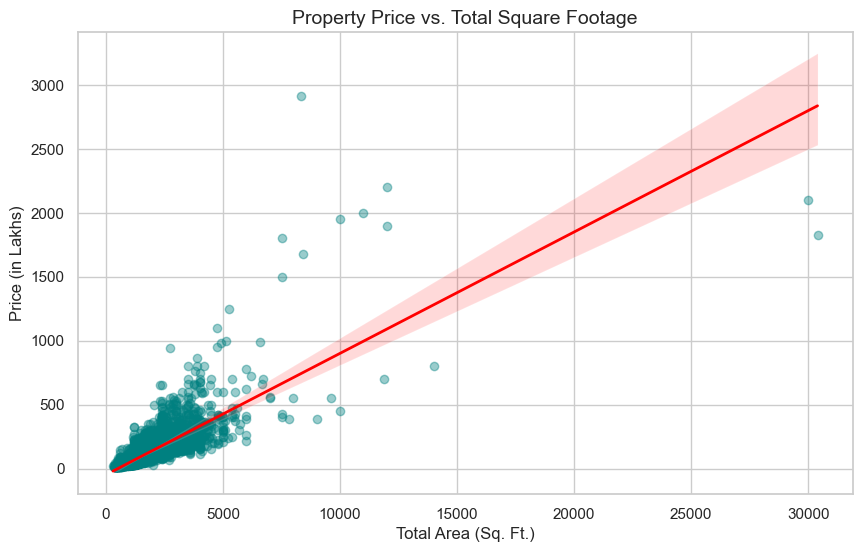

Pearson Correlation Coefficient between Area and Price: 0.80


In [5]:
plt.figure(figsize=(10, 6))

# Scatter plot with a regression trend line
sns.regplot(data=df, x='total_sqft', y='price', 
            scatter_kws={'alpha':0.4, 'color': 'teal'}, 
            line_kws={'color': 'red', 'linewidth': 2})

plt.title('Property Price vs. Total Square Footage', fontsize=14)
plt.xlabel('Total Area (Sq. Ft.)', fontsize=12)
plt.ylabel('Price (in Lakhs)', fontsize=12)

plt.show()

# Calculate Pearson Correlation
correlation = df['total_sqft'].corr(df['price'])
print(f"Pearson Correlation Coefficient between Area and Price: {correlation:.2f}")

C:\Users\varsh\AppData\Local\Temp\ipykernel_12504\2580643092.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_locations, x='location', y='price', order=location_order, palette='Set2')


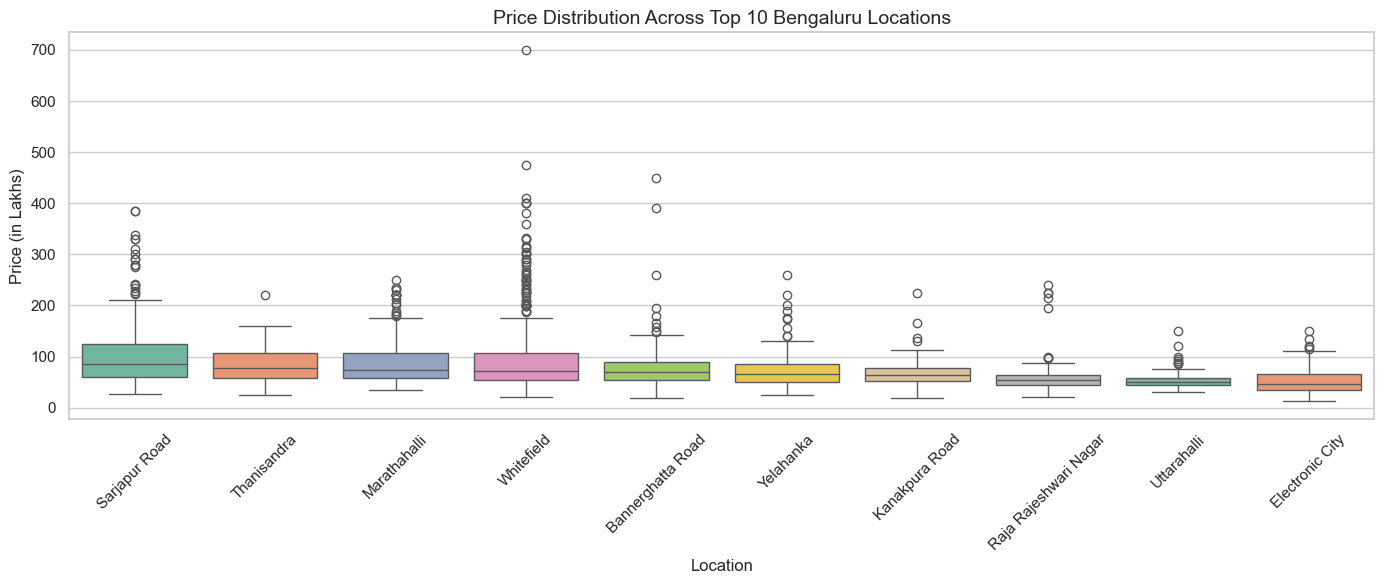

In [6]:
# Identify the top 10 most frequent locations
top_10_locations = df['location'].value_counts().head(10).index

# Filter the dataframe for only these locations
df_top_locations = df[df['location'].isin(top_10_locations)]

plt.figure(figsize=(14, 6))

# Boxplot sorted by median price
location_order = df_top_locations.groupby('location')['price'].median().sort_values(ascending=False).index

sns.boxplot(data=df_top_locations, x='location', y='price', order=location_order, palette='Set2')

plt.title('Price Distribution Across Top 10 Bengaluru Locations', fontsize=14)
plt.xlabel('Location', fontsize=12)
plt.ylabel('Price (in Lakhs)', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

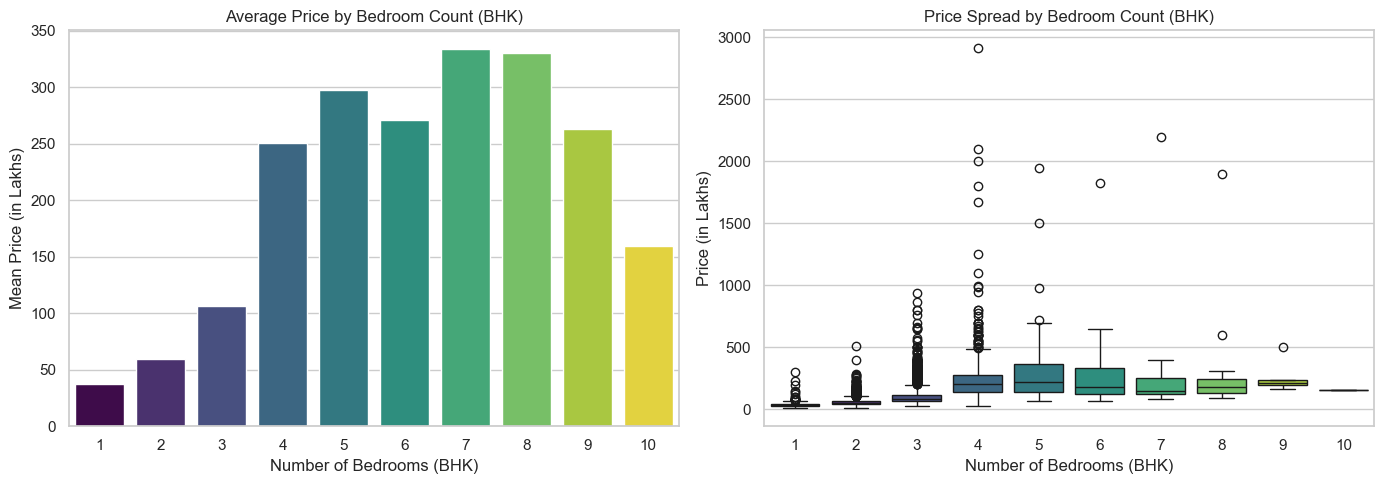

In [7]:
plt.figure(figsize=(14, 5))

# 1. Barplot showing Average Price per BHK
plt.subplot(1, 2, 1)
sns.barplot(data=df, x='bhk', y='price', estimator=np.mean, errorbar=None, palette='viridis', hue='bhk', legend=False)
plt.title('Average Price by Bedroom Count (BHK)', fontsize=12)
plt.xlabel('Number of Bedrooms (BHK)')
plt.ylabel('Mean Price (in Lakhs)')

# 2. Boxplot showing Price Spread per BHK
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='bhk', y='price', palette='viridis', hue='bhk', legend=False)
plt.title('Price Spread by Bedroom Count (BHK)', fontsize=12)
plt.xlabel('Number of Bedrooms (BHK)')
plt.ylabel('Price (in Lakhs)')

plt.tight_layout()
plt.show()

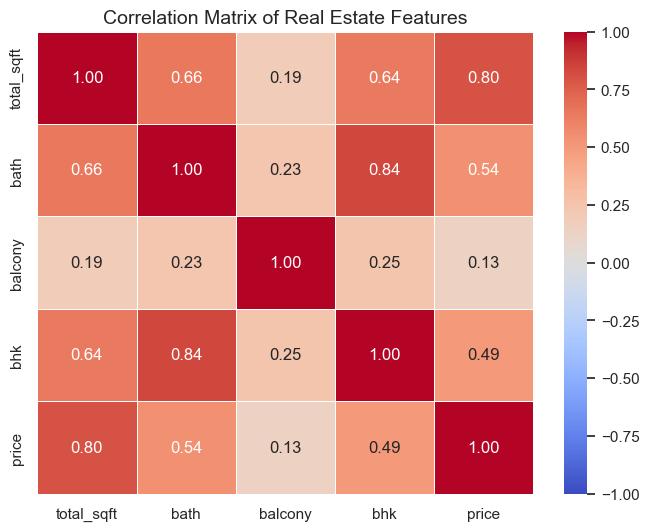

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

# Select only numerical features for correlation calculation
numerical_df = df[['total_sqft', 'bath', 'balcony', 'bhk', 'price']]

# Compute the Pearson correlation matrix
corr_matrix = numerical_df.corr()

# Plot the heatmap matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Real Estate Features', fontsize=14)

plt.show()


In [9]:
# Extract correlation values specifically relative to our target variable (price)
price_corr = corr_matrix['price'].drop('price').sort_values(ascending=False)

print("=== Correlation Relative to Price ===")
print(price_corr)
print("\n" + "="*40 + "\n")

# Define threshold rules to categorize our features
strong_positive = price_corr[price_corr >= 0.4].index.tolist()
strong_negative = price_corr[price_corr <= -0.4].index.tolist()
weak_predictors = price_corr[(price_corr > -0.4) & (price_corr < 0.4)].index.tolist()

print("🎯 Strong Positive Drivers (Moving up changes price upwards):")
print(f"   -> {strong_positive if strong_positive else 'None'}\n")

print("🛑 Strong Negative Drivers (Moving up changes price downwards):")
print(f"   -> {strong_negative if strong_negative else 'None'}\n")

print("⚠️ Weak Predictors (Little to no direct linear impact on price):")
print(f"   -> {weak_predictors if weak_predictors else 'None'}")

=== Correlation Relative to Price ===
total_sqft    0.800803
bath          0.543969
bhk           0.492726
balcony       0.134204
Name: price, dtype: float64


🎯 Strong Positive Drivers (Moving up changes price upwards):
   -> ['total_sqft', 'bath', 'bhk']

🛑 Strong Negative Drivers (Moving up changes price downwards):
   -> None

⚠️ Weak Predictors (Little to no direct linear impact on price):
   -> ['balcony']


=== Top 10 Most Expensive Neighborhoods (By Mean Price/Sqft) ===
                               mean  count
location                                  
Cunningham Road        20335.886586     11
Rajaji Nagar           13865.732515     71
Malleshwaram           11970.308819     41
Indira Nagar           11727.093230     38
Banashankari Stage II  11390.369320     13
Chamrajpet              9897.669668     11
Frazer Town             9748.286625     27
Koramangala             9669.579444     54
Basavangudi             9472.371310     18
Hosakerehalli           9140.872849     20


C:\Users\varsh\AppData\Local\Temp\ipykernel_12504\2424841865.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=expensive_neighborhoods['mean'], y=expensive_neighborhoods.index, palette='Reds_r')


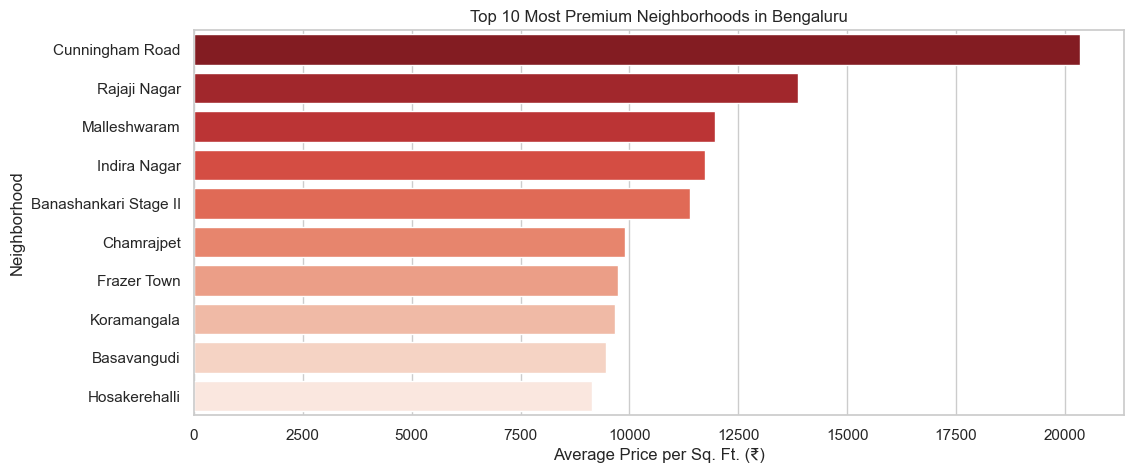

In [10]:
# Create a temporary working column for price per sqft to rank locations fairly
df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']

# Find locations with less than 10 listings
location_stats = df['location'].value_counts()
locations_less_than_10 = location_stats[location_stats <= 10]

# Group rare locations into 'other' to keep our analysis clean
df['location'] = df['location'].apply(lambda x: 'other' if x in locations_less_than_10 else x)

# Calculate average price per sqft per neighborhood
expensive_neighborhoods = df.groupby('location')['price_per_sqft'].agg(['mean', 'count'])\
                            .sort_values(by='mean', ascending=False)\
                            .head(10)

print("=== Top 10 Most Expensive Neighborhoods (By Mean Price/Sqft) ===")
print(expensive_neighborhoods)

# Plot the expensive areas
plt.figure(figsize=(12, 5))
sns.barplot(x=expensive_neighborhoods['mean'], y=expensive_neighborhoods.index, palette='Reds_r')
plt.title('Top 10 Most Premium Neighborhoods in Bengaluru')
plt.xlabel('Average Price per Sq. Ft. (₹)')
plt.ylabel('Neighborhood')
plt.show()

=== Top 10 High-Volume Emerging Neighborhoods ===
                       total_listings   avg_price      avg_pps
location                                                      
Whitefield                        460   97.923359  5496.560892
Sarjapur Road                     283  103.405777  5928.456649
Electronic City                   260   52.003423  4397.041779
Yelahanka                         168   73.281339  5037.026922
Kanakpura Road                    159   65.723616  4998.575845
Thanisandra                       155   82.618065  5796.119242
Raja Rajeshwari Nagar             152   59.815987  4275.016509
Bannerghatta Road                 142   82.211479  5325.734119
Marathahalli                      140   93.264929  5670.800800
Uttarahalli                       137   53.072628  4116.072653


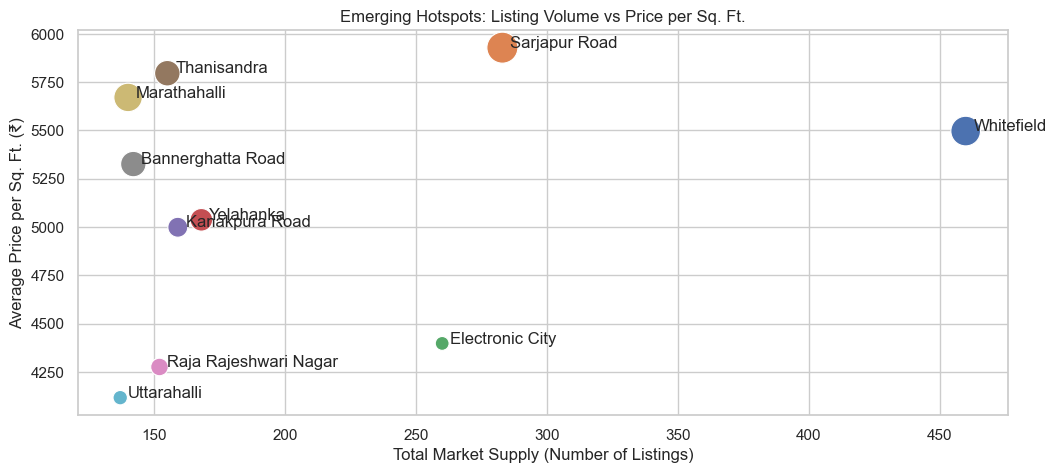

In [11]:
# Identify emerging areas by looking at the highest volume locations (excluding 'other')
emerging_areas = df[df['location'] != 'other'].groupby('location')\
                    .agg(total_listings=('price', 'count'), avg_price=('price', 'mean'), avg_pps=('price_per_sqft', 'mean'))\
                    .sort_values(by='total_listings', ascending=False)\
                    .head(10)

print("=== Top 10 High-Volume Emerging Neighborhoods ===")
print(emerging_areas)

# Plotting development volume vs price density
plt.figure(figsize=(12, 5))
sns.scatterplot(data=emerging_areas, x='total_listings', y='avg_pps', size='avg_price', sizes=(100, 500), hue=emerging_areas.index, legend=False)
for i, txt in enumerate(emerging_areas.index):
    plt.annotate(txt, (emerging_areas['total_listings'].iloc[i]+3, emerging_areas['avg_pps'].iloc[i]))
plt.title('Emerging Hotspots: Listing Volume vs Price per Sq. Ft.')
plt.xlabel('Total Market Supply (Number of Listings)')
plt.ylabel('Average Price per Sq. Ft. (₹)')
plt.show()

In [13]:
# Generate a clean geographical matrix for your Tableau dashboard mapping layer
tableau_geo_map = df.groupby('location').agg(
    Average_Price_Lakhs=('price', 'mean'),
    Median_Price_Lakhs=('price', 'median'),
    Avg_Price_Per_Sqft=('price_per_sqft', 'mean'),
    Total_Properties_Listed=('price', 'count')
).reset_index()

# Save it to your processed data folder
geo_output_path = ('C:\\Users\\varsh\\Downloads\\Real estate prediction model\\data\\processed\\tableau_geographic_insights.csv')
tableau_geo_map.to_csv(geo_output_path, index=False)

print(f"🎉 Success! Geographic summary dataset generated.")
print(f"File exported to your folder structure: {geo_output_path}")
print("You can open this file directly in Tableau to build an interactive map dashboard.")

🎉 Success! Geographic summary dataset generated.
File exported to your folder structure: C:\Users\varsh\Downloads\Real estate prediction model\data\processed\tableau_geographic_insights.csv
You can open this file directly in Tableau to build an interactive map dashboard.


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# fallback or normal seaborn
import seaborn as sns

# Reload fresh data if needed, making sure we have the raw availability column for extraction
df_raw = pd.read_csv(r'C:\Users\varsh\Downloads\Real estate prediction model\data\raw\Bengaluru_House_Data.csv')
df['availability'] = df_raw['availability']

def extract_year(x):
    if x == 'Ready To Move' or x == 'Immediate Possession':
        return 2018 # Assuming 2018 as the baseline capture year for this dataset
    try:
        # If it's a format like '19-Dec', split and get the 2-digit year
        tokens = x.split('-')
        if len(tokens) == 2:
            return int("20" + tokens[0].strip())
    except:
        return None
    return 2018

# Extract clean delivery year
df['delivery_year'] = df['availability'].apply(extract_year)

# Filter out a few extreme future anomalies (e.g., years > 2022) to keep trends realistic
df_trends = df[df['delivery_year'] <= 2022]

# Calculate Year-over-Year (YoY) average price trends
yearly_appreciation = df_trends.groupby('delivery_year')['price'].mean().reset_index()
print("=== Year-Wise Asset Appreciation ===")
print(yearly_appreciation)

=== Year-Wise Asset Appreciation ===
   delivery_year       price
0           2014   46.000000
1           2015   71.200000
2           2016   85.826667
3           2017  106.292187
4           2018   95.986350
5           2019   99.605619
6           2020  108.930991
7           2021   90.108945
8           2022   84.773030


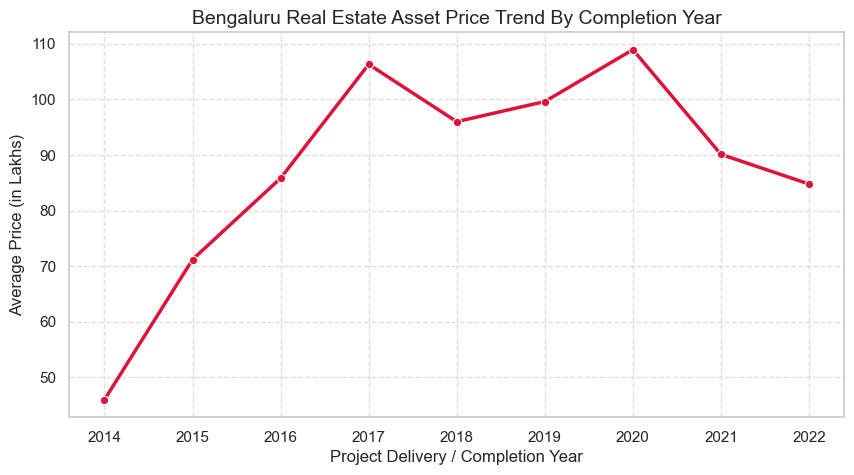

In [17]:
plt.figure(figsize=(10, 5))

# Plot line chart for price progression
sns.lineplot(data=yearly_appreciation, x='delivery_year', y='price', marker='o', color='crimson', linewidth=2.5)

plt.title('Bengaluru Real Estate Asset Price Trend By Completion Year', fontsize=14)
plt.xlabel('Project Delivery / Completion Year', fontsize=12)
plt.ylabel('Average Price (in Lakhs)', fontsize=12)
plt.xticks(yearly_appreciation['delivery_year'])
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

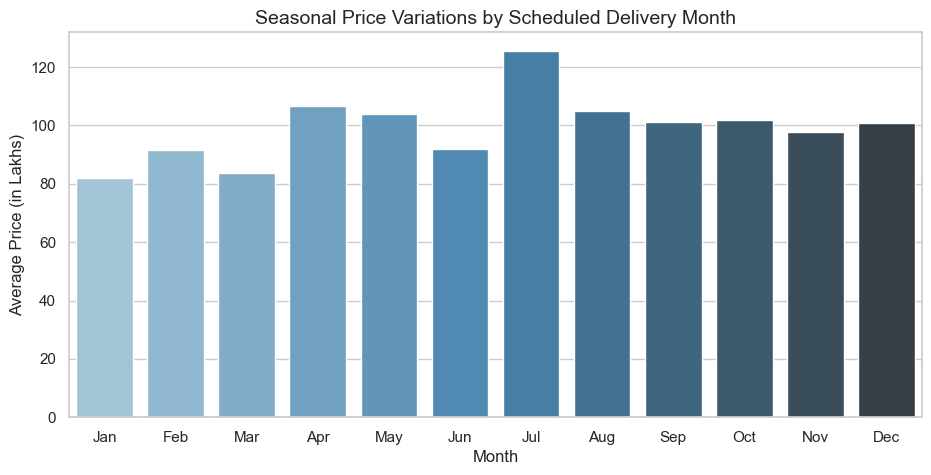

In [18]:
def extract_month(x):
    if x in ['Ready To Move', 'Immediate Possession']:
        return 'Ready'
    tokens = str(x).split('-')
    if len(tokens) == 2:
        return tokens[1].strip() # Returns Month name like 'Dec', 'Apr'
    return 'Ready'

df_trends['delivery_month'] = df_trends['availability'].apply(extract_month)

# Filter for only forward-looking monthly project schedules
df_months = df_trends[df_trends['delivery_month'] != 'Ready']

# Sort months chronologically for the chart
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
seasonal_metrics = df_months.groupby('delivery_month')['price'].mean().reindex(month_order).reset_index()

# Plot seasonal price launch trends
plt.figure(figsize=(11, 5))
sns.barplot(data=seasonal_metrics, x='delivery_month', y='price', palette='Blues_d', hue='delivery_month', legend=False)
plt.title('Seasonal Price Variations by Scheduled Delivery Month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Price (in Lakhs)', fontsize=12)
plt.show()

In [19]:
# Save clean trend matrix
df_trends.to_csv(r'C:\Users\varsh\Downloads\Real estate prediction model\data\processed/tableau_time_trends.csv', index=False)
print("🎉 Success! Time Trend Analysis complete.")
print("Saved trend analytics model sheet to: ../data/processed/tableau_time_trends.csv")

🎉 Success! Time Trend Analysis complete.
Saved trend analytics model sheet to: ../data/processed/tableau_time_trends.csv
